# Comparaison des 4 approches — Impact du data leakage

LinearSVC · GroupKFold(10) · ABIDE

1. PCA avant CV (leakage)
2. PCA dans CV (corrigé)
3. SelectKBest avant CV (leakage)
4. SelectKBest dans CV (corrigé)

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

from nilearn import datasets
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

import prepare_data_v2

In [2]:
data_dir   = os.environ.get("SOURCE_DATA_DIR", "../../data")
output_dir = os.environ.get("OUTPUT_DATA_DIR", "../output")

X, y = prepare_data_v2.prepare_data(data_dir, output_dir)
X = np.array(X)
y = np.array(y)

abide  = datasets.fetch_abide_pcp(data_dir=data_dir, pipeline="cpac", quality_checked=True)
pheno  = pd.DataFrame(abide.phenotypic)
groups = [s.decode() if isinstance(s, bytes) else s for s in pheno.SITE_ID]

n_subjects = X.shape[0]
n_sites = len(set(groups))
print(f"{n_subjects} sujets · {n_sites} sites")

Chargement du dataset...
[fetch_abide_pcp] Dataset found in /home/evavi/abide-fmri/data/ABIDE_pcp


[fetch_atlas_basc_multiscale_2015] Dataset found in /home/evavi/nilearn_data/basc_multiscale_2015
Fichier de features trouvé.


[fetch_abide_pcp] Dataset found in /home/evavi/abide-fmri/data/ABIDE_pcp
871 sujets · 20 sites


In [3]:
gkf = GroupKFold(n_splits=10)

print("Approche 1 — PCA avant CV (leakage)...")
X_pca = PCA(0.99).fit_transform(X)
scores_pca_leakage = cross_val_score(LinearSVC(max_iter=10000), X_pca, y, groups=groups, cv=gkf, n_jobs=-1)

print("Approche 2 — PCA dans CV (corrigé)...")
scores_pca_corrected = cross_val_score(
    Pipeline([("pca", PCA(0.99)), ("clf", LinearSVC(max_iter=10000))]),
    X, y, groups=groups, cv=gkf, n_jobs=-1)

print("Approche 3 — SelectKBest avant CV (leakage)...")
X_kbest = SelectKBest(f_classif, k=100).fit_transform(X, y)
scores_kbest_leakage = cross_val_score(LinearSVC(max_iter=10000), X_kbest, y, groups=groups, cv=gkf, n_jobs=-1)

print("Approche 4 — SelectKBest dans CV (corrigé)...")
scores_kbest_corrected = cross_val_score(
    Pipeline([("selector", SelectKBest(f_classif, k=100)), ("clf", LinearSVC(max_iter=10000))]),
    X, y, groups=groups, cv=gkf, n_jobs=-1)

all_scores = [scores_pca_leakage, scores_pca_corrected, scores_kbest_leakage, scores_kbest_corrected]
print("Done!")

Approche 1 — PCA avant CV (leakage)...


Approche 2 — PCA dans CV (corrigé)...


Approche 3 — SelectKBest avant CV (leakage)...
Approche 4 — SelectKBest dans CV (corrigé)...


Done!


In [4]:
LABELS = ["PCA avant CV (leakage)", "PCA dans CV (corrigé)",
          "SelectKBest avant CV (leakage)", "SelectKBest dans CV (corrigé)"]

results = pd.DataFrame({"Approche": LABELS,
    "Accuracy moyenne": [s.mean() for s in all_scores],
    "Ecart-type":       [s.std()  for s in all_scores]})
print(results.to_string(index=False))
print(f"Biais PCA        : {abs(scores_pca_leakage.mean()   - scores_pca_corrected.mean()):.4f}")
print(f"Biais SelectKBest: {abs(scores_kbest_leakage.mean() - scores_kbest_corrected.mean()):.4f}")

                      Approche  Accuracy moyenne  Ecart-type
        PCA avant CV (leakage)          0.635624    0.062821
         PCA dans CV (corrigé)          0.652825    0.047497
SelectKBest avant CV (leakage)          0.648156    0.039943
 SelectKBest dans CV (corrigé)          0.610467    0.051309
Biais PCA        : 0.0172
Biais SelectKBest: 0.0377


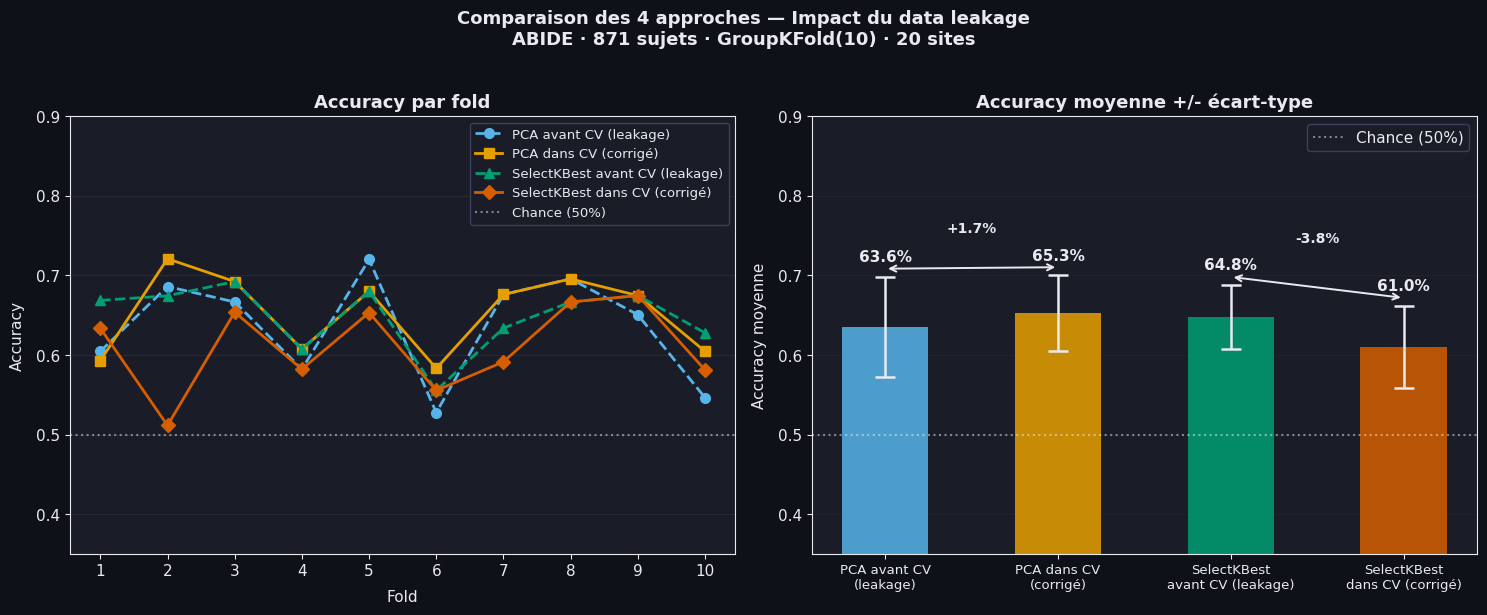

In [5]:
BG     = '#0e1117'
PANEL  = '#1a1d27'
TEXT   = '#e8eaf0'
COLORS = ['#56B4E9', '#E69F00', '#009E73', '#D55E00']
LABELS_BAR = [
    'PCA avant CV\n(leakage)',
    'PCA dans CV\n(corrigé)',
    'SelectKBest\navant CV (leakage)',
    'SelectKBest\ndans CV (corrigé)',
]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor':   PANEL,
    'axes.edgecolor':   TEXT, 'axes.labelcolor':  TEXT,
    'xtick.color':      TEXT, 'ytick.color':      TEXT,
    'text.color':       TEXT, 'legend.facecolor': PANEL,
    'legend.edgecolor': '#444466', 'font.size':   11,
    'axes.titlesize':   13, 'axes.titleweight': 'bold',
    'grid.color':       '#2a2d3a', 'grid.linewidth': 0.6,
})

n_folds = len(all_scores[0])
folds   = np.arange(n_folds)
markers = ['o', 's', '^', 'D']
lines   = ['--', '-', '--', '-']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

ax = axes[0]
for scores, label, color, marker, line in zip(all_scores, LABELS, COLORS, markers, lines):
    ax.plot(folds, scores, marker=marker, linestyle=line, label=label,
            color=color, linewidth=2, markersize=7)
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5, label='Chance (50%)')
ax.set_xlabel('Fold', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Accuracy par fold')
ax.set_xticks(folds)
ax.set_xticklabels([str(i + 1) for i in folds])
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(framealpha=0.85, fontsize=9.5)

ax    = axes[1]
means = [s.mean() for s in all_scores]
stds  = [s.std()  for s in all_scores]
x_pos = np.arange(4)
bars  = ax.bar(x_pos, means, yerr=stds, capsize=7,
               color=COLORS, alpha=0.85, width=0.5,
               error_kw={'ecolor': TEXT, 'elinewidth': 1.8, 'capthick': 1.8})
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5, label='Chance (50%)')
ax.set_ylabel('Accuracy moyenne', labelpad=8)
ax.set_title('Accuracy moyenne +/- écart-type')
ax.set_xticks(x_pos)
ax.set_xticklabels(LABELS_BAR, fontsize=9.5)
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(framealpha=0.85)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.015,
            f'{mean:.1%}', ha='center', va='bottom',
            fontweight='bold', color=TEXT, fontsize=11)

def annotate_diff(ax, x1, x2, y1, y2, stds):
    diff  = y2 - y1
    sign  = '+' if diff >= 0 else ''
    mid_x = (x1 + x2) / 2
    mid_y = max(y1 + stds[x1], y2 + stds[x2]) + 0.05
    ax.annotate('', xy=(x2, y2 + stds[x2] + 0.01), xytext=(x1, y1 + stds[x1] + 0.01),
                arrowprops=dict(arrowstyle='<->', color=TEXT, lw=1.4))
    ax.text(mid_x, mid_y, f'{sign}{diff:.1%}', ha='center', va='bottom',
            color=TEXT, fontsize=10, fontweight='bold')

annotate_diff(ax, 0, 1, means[0], means[1], stds)
annotate_diff(ax, 2, 3, means[2], means[3], stds)

fig.suptitle(
    f'Comparaison des 4 approches — Impact du data leakage\n'
    f'ABIDE · {n_subjects} sujets · GroupKFold(10) · {n_sites} sites',
    fontsize=13, fontweight='bold', color=TEXT, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Tache_3b_comparaison.png'), bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
